# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-18 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-18 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet18, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

2025-03-19 08:34:12.414674: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 08:34:12.425632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742373252.440774    8758 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742373252.445782    8758 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-19 08:34:12.459164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Core Variables

In [2]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'resnet_18' # Name of the model to be saved
BEST_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_best_model.keras'
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_pneumonia_model.keras'

# Training parameters
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.3
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

# Data Loading & Preprocessing

In [3]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(DATA_PATH)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Creation & Compilation

In [4]:
# Create and compile model
model = build_resnet18(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

I0000 00:00:1742373255.003584    8758 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1985 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │     36,928 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ maxpool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 14, 14,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 14, 14,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 14, 14,    │        256 │ stage1_block2_co

 Total params: 11,183,106 (42.66 MB)

 Trainable params: 11,173,506 (42.62 MB)

 Non-trainable params: 9,600 (37.50 KB)

## Callback Definition

In [5]:
# Get callbacks
callbacks = get_callbacks(BEST_MODEL_PATH, monitor=CHOSEN_METRIC, mode='max')
dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=EPOCHS)
callbacks.append(dropout_scheduler)

## Training

Epoch 1: dropout rate set to 0.5000
Epoch 1/50


I0000 00:00:1742373263.802172    8812 service.cc:148] XLA service 0x731c70044ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742373263.802251    8812 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-03-19 08:34:24.046670: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742373265.161274    8812 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-19 08:34:25.942693: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"c

  2/148 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - AUC: 0.7126 - accuracy: 0.6562 - loss: 0.8704  

I0000 00:00:1742373273.628584    8812 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


146/148 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - AUC: 0.9418 - accuracy: 0.8823 - loss: 0.4382

2025-03-19 08:34:41.445689: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-19 08:34:41.538328: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFo

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - AUC: 0.9421 - accuracy: 0.8827 - loss: 0.4363

2025-03-19 08:34:51.025014: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-19 08:34:51.158032: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

148/148 ━━━━━━━━━━━━━━━━━━━━ 37s 134ms/step - AUC: 0.9422 - accuracy: 0.8829 - loss: 0.4353 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 1.6787 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4960
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - AUC: 0.9831 - accuracy: 0.9364 - loss: 0.1778 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 1.9904 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4920
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - AUC: 0.9932 - accuracy: 0.9614 - loss: 0.1013 - val_AUC: 0.7452 - val_accuracy: 0.7424 - val_loss: 1.9722 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4880
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - AUC: 0.9950 - accuracy: 0.9659 - loss: 0.0859 - val_AUC: 0.9679 - val_accuracy: 0.9141 - val_loss: 0.2668 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4840
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - AUC: 0.9978 - accuracy: 0.9774 - loss: 0.0595 - val_AUC: 0.9741 - val_

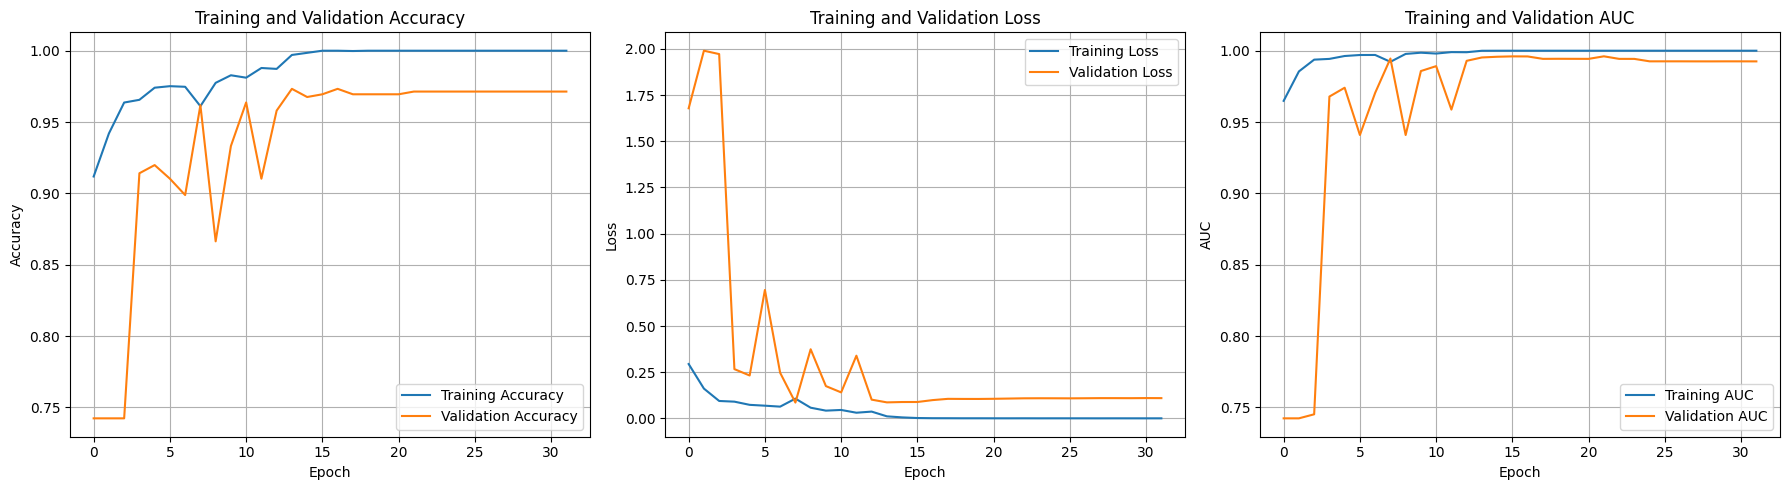

In [6]:
# Train model
history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

14/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8826 - accuracy: 0.8541 - loss: 1.4455

2025-03-19 08:38:21.295628: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-19 08:38:21.408983: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - AUC: 0.8896 - accuracy: 0.8567 - loss: 1.3443
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


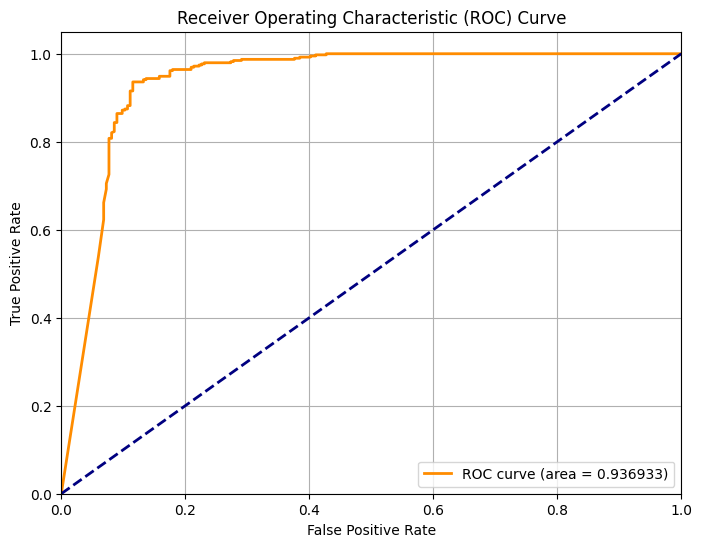

ROC AUC Score: 0.9369


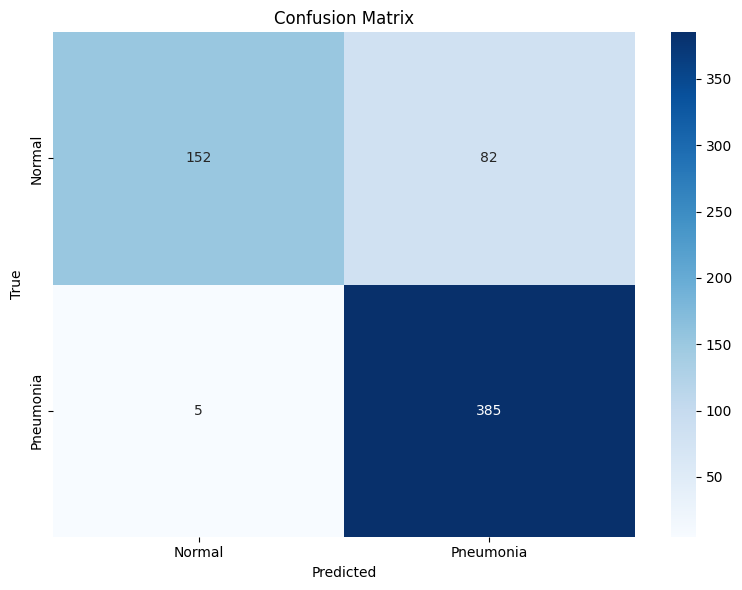

              precision    recall  f1-score   support

      Normal       0.97      0.65      0.78       234
   Pneumonia       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624



In [7]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Comparison

In [8]:
# Load best model from training
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Compare with final model
results_best, results_final = compare_models(best_model, model, test_images, test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - AUC: 0.8896 - accuracy: 0.8567 - loss: 1.3443
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.8896 - accuracy: 0.8567 - loss: 1.3443
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Best Model (in Training) vs Selected Model (through callbacks):
Test accuracy: 0.860577 vs 0.860577
Test AUC: 0.936933 vs 0.936933
